# Visualising chemical data

```{admonition} Learning outcomes
After working through this topic, you should be able to:

1. choose a visualisation that fits the chemical data and question
2. use Matplotlib to make scatter and line plots
3. create figures with axis labels, units, legends and appropriate scaling
4. visualise several data series and several axes in one figure
5. explain what a figure shows — and what it does not show
```

Handling data is an increasingly important part of chemistry. A central part of data handling is making informative figures that allow us to inspect patterns and communicate results. Programming gives us control over both data processing and visualisation and makes it possible to repeat the same procedure when new data arrive.

A figure is not decoration. Choices of plot type, axes and scale influence what we notice. A good chemical figure should make it easier to answer a scientific question.

```{admonition} Data visualisation
Data visualisation is the graphical representation of data so that patterns, variation and relationships can be investigated and communicated more effectively.
```

Before choosing a figure, ask:

- What does each data point represent?
- Which variable was controlled, and which was measured?
- Are the points independent, or do they have a natural order?
- Should the figure show raw measurements, a summary, or a model?

## Scatter plots of measurement data

For a small dataset we can enter the values directly in lists. Suppose the vapour pressure of water has been measured at several temperatures:

| Temperature (°C) | Vapour pressure (kPa) |
|---:|---:|
| 16 | 1.817 |
| 18 | 2.063 |
| 20 | 2.339 |
| 22 | 2.644 |
| 24 | 2.984 |

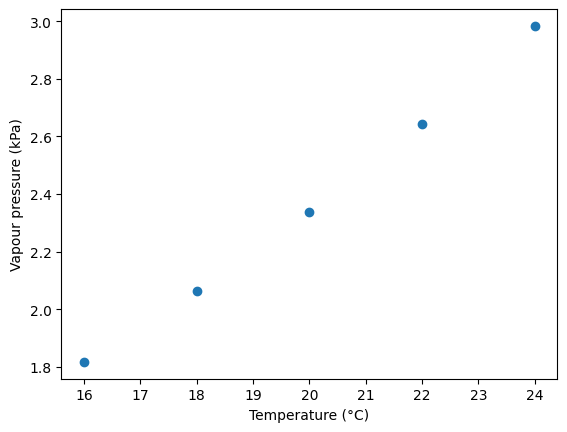

In [1]:
import matplotlib.pyplot as plt

temperature_C = [16, 18, 20, 22, 24]
vapour_pressure_kPa = [1.817, 2.063, 2.339, 2.644, 2.984]

plt.scatter(temperature_C, vapour_pressure_kPa)
plt.xlabel("Temperature (°C)")
plt.ylabel("Vapour pressure (kPa)")
plt.show()

`scatter` makes a scatter plot. Each point connects one temperature with the corresponding vapour-pressure measurement. Temperature is the independent variable chosen for the experiment, while vapour pressure is the measured dependent variable.

The lists must have the same length. Values at the same index belong together.

### Units and axis labels

A figure without labels and units is difficult to interpret. Use `xlabel` and `ylabel` to state what the axes represent, with the unit in parentheses. The numerical values themselves should normally remain numbers rather than strings such as `"2.0 kPa"`; otherwise Python cannot treat them directly as numerical data.

We can also add a title, grid, label and legend:

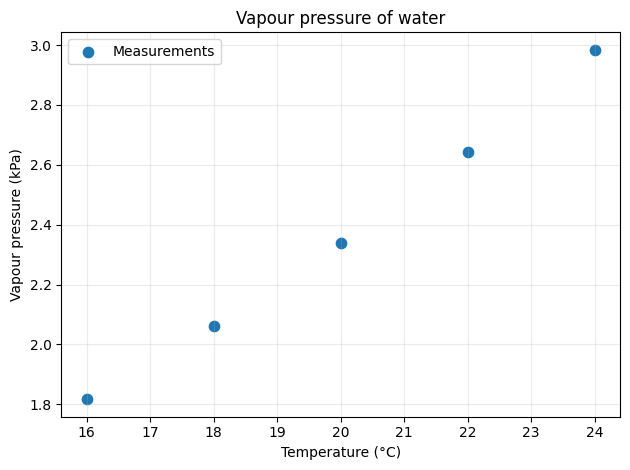

In [2]:
import matplotlib.pyplot as plt

temperature_C = [16, 18, 20, 22, 24]
vapour_pressure_kPa = [1.817, 2.063, 2.339, 2.644, 2.984]

plt.scatter(temperature_C, vapour_pressure_kPa, s=55, label="Measurements")
plt.xlabel("Temperature (°C)")
plt.ylabel("Vapour pressure (kPa)")
plt.title("Vapour pressure of water")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

`tight_layout()` adjusts spacing so that labels are not cut off. Marker style and size can improve readability, but the design should not overwhelm the data.

You can run and modify the vapour-pressure example in the editor below.

<iframe src="../../basthon/?from=examples/visualization_vapor_pressure.py" width="100%" height="620" frameborder="0" title="Interactive Python editor for visualising vapour-pressure data" loading="lazy" allowfullscreen></iframe>

````{admonition} Check your understanding
:class: tip

1. Change the marker size.
2. Remove one axis label. What information is lost?
3. Add a measurement at 26 °C and 3.36 kPa.
4. Reverse the two lists in `plt.scatter`. How does that change the scientific presentation?

```{admonition} Suggested answer
:class: tip, dropdown
Add `26` to `temperature_C` and `3.36` to `vapour_pressure_kPa`; the lists must still have equal length. Reversing the arguments presents temperature as a function of vapour pressure. The points contain the same pairs of values, but the plot is framed around a different question.
```
````

## Should the points be connected?

`plot` draws lines between points by default. That can be appropriate when the observations have a natural order, for example a time series:

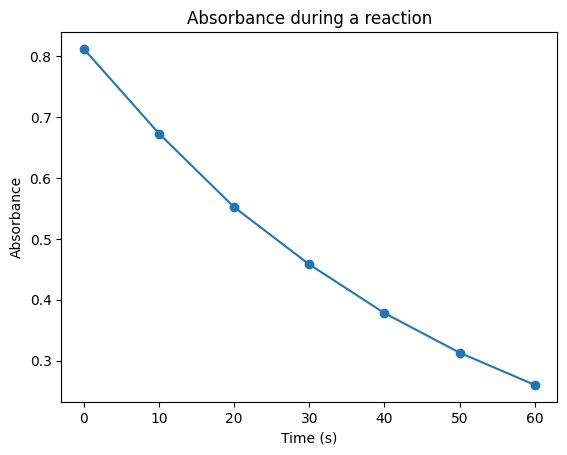

In [3]:
import matplotlib.pyplot as plt

time_s = [0, 10, 20, 30, 40, 50, 60]
absorbance = [0.812, 0.673, 0.552, 0.458, 0.378, 0.313, 0.260]

plt.plot(time_s, absorbance, marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Absorbance")
plt.title("Absorbance during a reaction")
plt.show()

The line makes the temporal sequence easier to follow. It does **not** mean that we measured every time between the points. The line is a visual connection, not by itself a continuous chemical model.

For calibration standards, a scatter plot is usually the better starting point. The standards are separate samples. If a line is shown, it should normally represent an explicit regression model rather than merely joining measurements in ascending order.

```{admonition} Rule of thumb
Use a scatter plot when you want to show individual measurements and the relationship between two quantities. Use lines when order is meaningful or when the line represents an explicit model.
```

You can inspect the time series in the editor below.

<iframe src="../../basthon/?from=examples/visualization_kinetics.py" width="100%" height="620" frameborder="0" title="Interactive Python editor for visualising reaction-kinetics data" loading="lazy" allowfullscreen></iframe>

````{admonition} Check your understanding
:class: tip

1. Replace `plt.plot` with `plt.scatter`. What becomes easier or harder to see?
2. Remove the markers from the line plot. Which information becomes less explicit?
3. Describe the chemical trend without claiming more than the data show.

```{admonition} Suggested answer
:class: tip, dropdown
The absorbance decreases rapidly at first and more slowly later. If absorbance is proportional to the concentration of one absorbing species, this is consistent with that species decreasing in concentration. The plot alone does not establish a reaction order or mechanism.
```
````

## Several data series in one figure

We can compare datasets in the same coordinate system. Use distinguishable markers or line styles and clear labels so the plot does not rely on colour alone.

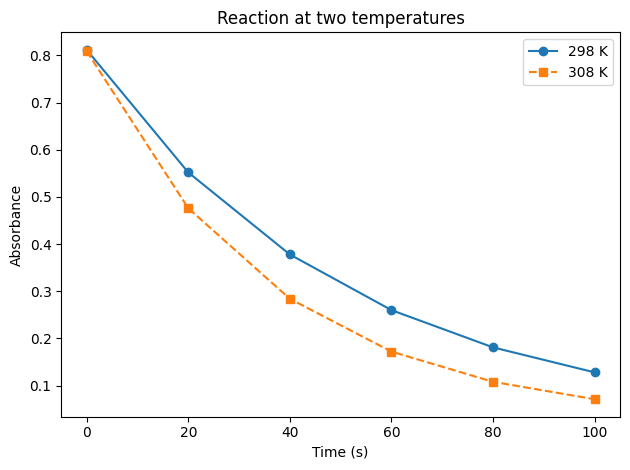

In [4]:
import matplotlib.pyplot as plt

time_s = [0, 20, 40, 60, 80, 100]
absorbance_298_K = [0.812, 0.552, 0.378, 0.260, 0.181, 0.128]
absorbance_308_K = [0.809, 0.476, 0.284, 0.172, 0.108, 0.071]

plt.plot(time_s, absorbance_298_K, marker="o", label="298 K")
plt.plot(time_s, absorbance_308_K, marker="s", linestyle="--", label="308 K")
plt.xlabel("Time (s)")
plt.ylabel("Absorbance")
plt.title("Reaction at two temperatures")
plt.legend()
plt.tight_layout()
plt.show()

A good legend lets readers distinguish the data series even in greyscale or with reduced colour vision.

````{admonition} Check your understanding
:class: tip
Which reaction mixture appears to change fastest? Is the figure alone sufficient to conclude that temperature caused the difference?

```{admonition} Suggested answer
:class: tip, dropdown
Absorbance decreases faster at 308 K. If temperature is the only systematic difference between the experiments, the result supports faster reaction at the higher temperature. The figure itself does not document the experimental controls, so causal interpretation still depends on the experimental design.
```
````

## Several plots in one figure

Putting every dataset on the same axes can become crowded. `subplots` lets us create separate coordinate systems while retaining a common figure.

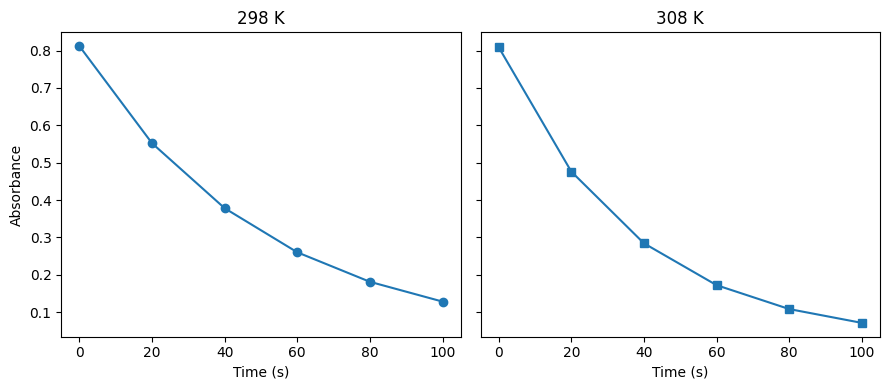

In [5]:
import matplotlib.pyplot as plt

time_s = [0, 20, 40, 60, 80, 100]
absorbance_298_K = [0.812, 0.552, 0.378, 0.260, 0.181, 0.128]
absorbance_308_K = [0.809, 0.476, 0.284, 0.172, 0.108, 0.071]

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(9, 4))

axes[0].plot(time_s, absorbance_298_K, marker="o")
axes[0].set_title("298 K")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Absorbance")

axes[1].plot(time_s, absorbance_308_K, marker="s")
axes[1].set_title("308 K")
axes[1].set_xlabel("Time (s)")

fig.tight_layout()
plt.show()

`axes` contains the two coordinate systems. `axes[0]` is the first and `axes[1]` the second. `sharey=True` gives both panels the same y-axis scale, preventing visual differences from being created simply by changing the axis range.

For a single plot, the simple `plt.scatter`, `plt.xlabel`, ... style is perfectly adequate. The object-oriented `fig, ax = plt.subplots()` approach becomes particularly useful when figures contain several axes.

## Axis limits and visual integrity

Axis limits can be changed with `xlim` and `ylim`, but the choice needs scientific justification. A narrow y-range can make a small difference look dramatic; a very wide range can make a meaningful difference look negligible.

Compare the same data with two y-axis choices:

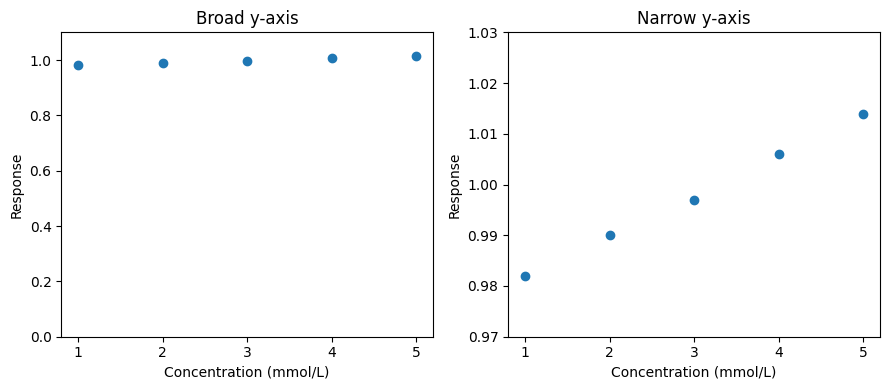

In [6]:
concentration_mM = [1, 2, 3, 4, 5]
response = [0.982, 0.990, 0.997, 1.006, 1.014]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].scatter(concentration_mM, response)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Broad y-axis")

axes[1].scatter(concentration_mM, response)
axes[1].set_ylim(0.97, 1.03)
axes[1].set_title("Narrow y-axis")

for ax in axes:
    ax.set_xlabel("Concentration (mmol/L)")
    ax.set_ylabel("Response")

fig.tight_layout()
plt.show()

Both plots are numerically correct, but they create different visual impressions. The solution is not a universal rule that every axis must start at zero. The solution is to choose limits that reveal the scientifically relevant variation without misleading the reader, and to label the axes clearly.

### Logarithmic axes

Logarithmic axes are useful when values span several orders of magnitude.

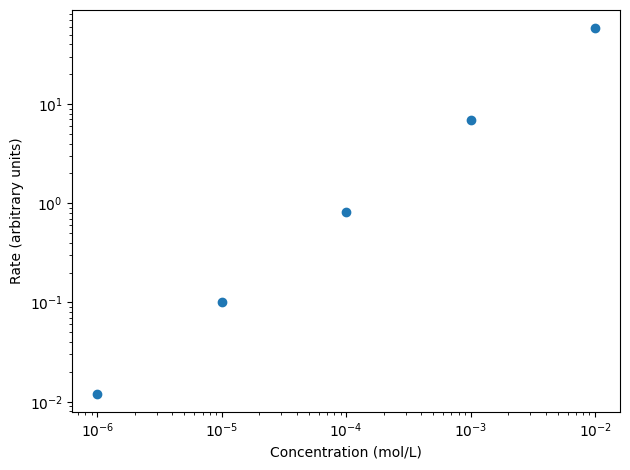

In [7]:
concentration_M = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
rate = [0.012, 0.10, 0.82, 6.9, 58]

plt.scatter(concentration_M, rate)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Concentration (mol/L)")
plt.ylabel("Rate (arbitrary units)")
plt.tight_layout()
plt.show()

A logarithmic scale changes how equal distances on the axis should be interpreted. It must therefore be visible from the ticks and labels and should be used because it helps answer a scientific question, not merely because it makes a pattern look straighter.

## What makes a good chemical figure?

Before finalising a figure, check:

- Are the variables and units explicit?
- Does the plot type fit the measurement design?
- Are raw data shown when variation between measurements matters?
- If several data series are present, can they be distinguished without colour alone?
- Are axis limits and scales defensible?
- Does a line represent a natural order, an interpolation or a model — and is that clear?
- Is the figure readable without unnecessary decoration?
- Can you state a chemical interpretation without over-interpreting the data?

## Exercises

```{admonition} Exercise 1.1 — vapour pressure
:class: tip
Extend the vapour-pressure dataset to include 26, 28 and 30 °C. Make a labelled scatter plot. Then make a second version using a line. Which representation do you prefer for the measurements, and why?
```

```{admonition} Exercise 1.2 — reaction kinetics
:class: tip
Use the time and absorbance values from the chapter. Make a figure that shows both points and a connecting line. Explain exactly what the points represent and what the line does and does not represent.
```

```{admonition} Exercise 1.3 — two temperatures
:class: tip
Plot the 298 K and 308 K datasets in the same axes. Use different marker shapes and line styles as well as a legend. Write two sentences that distinguish observation from causal interpretation.
```

```{admonition} Exercise 1.4 — data from a file
:class: tip
Read `data/reaction_kinetics.csv` with Pandas and visualise absorbance as a function of time. Use both points and a line, and describe the trend using chemical language.
```

```{admonition} Exercise 1.5 — subplots
:class: tip
Display the two temperature series in two side-by-side panels with a shared y-axis. Then remove `sharey=True`. Explain why separately scaled axes can make visual comparison harder.
```

```{admonition} Exercise 1.6 — axis choices
:class: tip
Create two figures from the same data using different y-axis limits. Identify a choice that exaggerates the apparent difference and one that hides it. Propose a defensible axis range and justify it.
```

```{admonition} Exercise 1.7 — logarithmic scale
:class: tip
Construct a dataset covering at least four orders of magnitude and compare linear and logarithmic axes. Explain what becomes easier to inspect on the logarithmic plot.
```

```{admonition} Exercise 1.8 — combined UV–Vis case
:class: tip
The file `data/uvvis_calibration.csv` contains blanks, calibration standards and an unknown sample. Make an exploratory scatter plot of absorbance against concentration using only the known standards and blanks. Show every replicate. What information would be lost if you replaced each concentration by a single mean value before plotting?
```